## In this notebook, we are implementing [YOLO](https://arxiv.org/pdf/1506.02640) algorithm from the paper 

<b>
    Highlights of YOLO as below
    <ol>Pros:
        <li>YOLO is extremely fast. Frame detection as a regression problem we don’t need a complex pipeline</li>
        <li>YOLO reasons globally about the image when making predictions. Because of this it produce less background error compared to Fast R-CNN</li>
        <li>YOLO learns generalizable representations of objects. When tested on different domain like artwork, it works fine.</li>
    </ol> 
    <ol> Cons:
        <li>It struggle to localize some objects, especially small ones.</li>
        <li>YOLO imposes strong spatial constraints on bounding
box predictions since each grid cell only predicts two boxes
and can only have one class. This spatial constraint lim-
its the number of nearby objects that our model can pre-
dict. Our model struggles with small objects that appear in
groups, such as flocks of birds.</li>
    </ol>
</b>

#### Training workflow
[Training procedure:](#)
<b> 
    Initially, pretrain convolution layer on the ImageNet 1000-class dataset. Once it achieved 88% on the ImageNet validation set, add four convolutional layer and two fully connected layers to train on object detection.  
</b>
[Training Loss function:](#)
<b>
    $$
\begin{aligned}
\mathcal{L} =\;&
\lambda_{\text{coord}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
\left[
(x_i-\hat{x}_i)^2 + (y_i-\hat{y}_i)^2
\right]
\\[6pt]
&+
\lambda_{\text{coord}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
\left[
(\sqrt{w_i}-\sqrt{\hat{w}_i})^2
+
(\sqrt{h_i}-\sqrt{\hat{h}_i})^2
\right]
\\[6pt]
&+
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{obj}}
(C_i-\hat{C}_i)^2
\\[6pt]
&+
\lambda_{\text{noobj}}
\sum_{i=0}^{S^2}
\sum_{j=0}^{B}
\mathbf{1}_{ij}^{\text{noobj}}
(C_i-\hat{C}_i)^2
\\[6pt]
&+
\sum_{i=0}^{S^2}
\mathbf{1}_{i}^{\text{obj}}
\sum_{c \in \text{classes}}
\left(
p_i(c)-\hat{p}_i(c)
\right)^2
\end{aligned}
$$
where $ \mathbf{1}_{i}^{\text{noobj}} $ denotes if object appears in cell i and   $ \mathbf{1}_{ij}^{\text{noobj}} $ de-
notes that the jth bounding box predictor in cell i is “responsible” for that prediction.
</b>

In [1]:
import torch
import cv2
from torchvision.datasets import VOCDetection
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets

from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,

from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

from dataclasses import dataclass

import numpy as np
import random
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

### Training Configuration Parameters

In [3]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 64
    num_epochs: int = 40
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./data/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


### Load the dataset

In [4]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=False,
    transform=transform
)


print(f"Training dataset {len(dataset)}")

validation_dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=False,
    transform=transform
)

print(f"Validation dataset {len(validation_dataset)}")

image, target = dataset[0]
print(target.keys())

Training dataset 5717
Validation dataset 5823
dict_keys(['annotation'])


### Data Loader Preparation

In [5]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    dataset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers,
    collate_fn=collate_fn
)

In [6]:
object_classes = set()

In [9]:
images, labels = next(iter(train_loader))

for val in labels:
    for obj in val['annotation']['object']:
        object_classes.add(obj['name'])

In [10]:
classes_idx = {}
for idx,target in enumerate(sorted(object_classes)):
    classes_idx[target] = idx

print(classes_idx)

{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


### Visualize the dataset

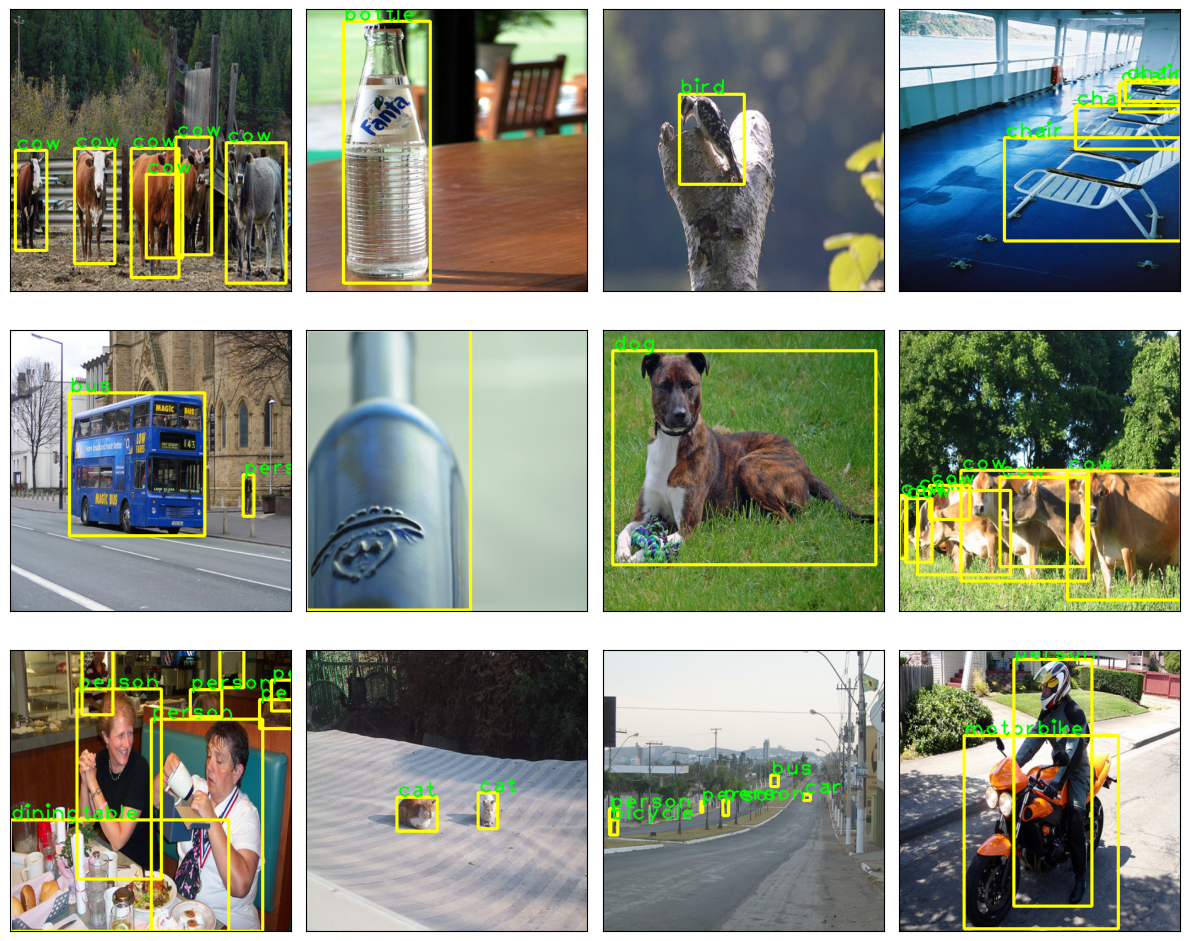

In [11]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        # Convert to OpenCV image
        tensor_img = image.clone()
        
        img = tensor_img.permute(1, 2, 0).cpu().numpy()  # HWC
        img = (img * 255).astype(np.uint8)
        img = np.ascontiguousarray(img)

        
        
        #'size': {'width': '500', 'height': '442', 'depth': '3'}

        orig_w = int(label['annotation']['size']['width'])
        orig_h = int(label['annotation']['size']['height'])
        new_w = 448
        new_h = 448

        scale_x = new_w / orig_w
        scale_y = new_h / orig_h

        for obj_element in label['annotation']['object']:
            x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
            y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
            x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
            y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)
            
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max) , (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
            cv2.putText(img, obj_element['name'], (x_min,y_min),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2)        
       
        ax.imshow(img, cmap='gray')

        #ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()
    #plt.savefig('voc_dataset.pdf', dpi=300, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)


#### YOLO 20 layer pretrain + 4 conv layer + 2 fully connected layer

In [12]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 3

        self._model = nn.Sequential(
            #-------Convolution Layer-------
            #layer   filters  size           input                 output
            #0 conv     16  3 x 3 / 1   224 x 224 x   3   ->   224 x 224 x  16
            #1 max          2 x 2 / 2   224 x 224 x  16   ->   112 x 112 x  16
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            #2 conv     32  3 x 3 / 1   112 x 112 x  16   ->   112 x 112 x  32
            #3 max          2 x 2 / 2   112 x 112 x  32   ->    56 x  56 x  32
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            
            #4 conv     16  1 x 1 / 1    56 x  56 x  32   ->    56 x  56 x  16
            #5 conv    128  3 x 3 / 1    56 x  56 x  16   ->    56 x  56 x 128
            #6 conv     16  1 x 1 / 1    56 x  56 x 128   ->    56 x  56 x  16
            #7 conv    128  3 x 3 / 1    56 x  56 x  16   ->    56 x  56 x 128
            #8 max          2 x 2 / 2    56 x  56 x 128   ->    28 x  28 x 128
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=16, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=128, out_channels=16, kernel_size=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=16, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            # 9 conv     32  1 x 1 / 1    28 x  28 x 128   ->    28 x  28 x  32
            #10 conv    256  3 x 3 / 1    28 x  28 x  32   ->    28 x  28 x 256
            #11 conv     32  1 x 1 / 1    28 x  28 x 256   ->    28 x  28 x  32
            #12 conv    256  3 x 3 / 1    28 x  28 x  32   ->    28 x  28 x 256
            #13 max          2 x 2 / 2    28 x  28 x 256   ->    14 x  14 x 256
            nn.Conv2d(in_channels=128, out_channels=32, kernel_size=1, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=32, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=256, out_channels=32, kernel_size=1, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=32, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            #14 conv     64  1 x 1 / 1    14 x  14 x 256   ->    14 x  14 x  64
            #15 conv    512  3 x 3 / 1    14 x  14 x  64   ->    14 x  14 x 512
            #16 conv     64  1 x 1 / 1    14 x  14 x 512   ->    14 x  14 x  64
            #17 conv    512  3 x 3 / 1    14 x  14 x  64   ->    14 x  14 x 512
            #18 conv    128  1 x 1 / 1    14 x  14 x 512   ->    14 x  14 x 128
            #19 conv   512  3 x 3 / 1    14 x  14 x 128   ->    14 x  14 x 512
            nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=512, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=512, out_channels=128, kernel_size=1, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=128, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.01),
            
            #20 conv 1024  3 x 3 / 1   
            #21 conv 1024  3 x 3 / 2
            #22 conv 1024  3 x 3 / 1
            #23 conv 1024  3 x 3 / 1
            nn.Conv2d(in_channels=512, out_channels=1024, stride = 2,kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=1024, out_channels=1024, stride = 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Flatten(),

            # Fully Connected layer (4096)
            # Final Connected layer 7x7x30 (1470)
            nn.Linear(in_features=7 * 7 * 1024, out_features=4096),                            # Linear 1
            nn.Dropout(),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Linear(in_features=4096, out_features= 1470)
        )
        
    def forward(self, x):
        return self._model(x)

In [13]:
model = Model()

#model.load_state_dict(torch.load("best.pt",  map_location=DEVICE))

model = model.to(DEVICE)

#optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate)
optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.0001)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,448,448)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 1470]                 --
├─Sequential (_model)                    [1, 1470]                 --
│    └─Conv2d (0)                        [1, 16, 448, 448]         448
│    └─BatchNorm2d (1)                   [1, 16, 448, 448]         32
│    └─LeakyReLU (2)                     [1, 16, 448, 448]         --
│    └─MaxPool2d (3)                     [1, 16, 224, 224]         --
│    └─Conv2d (4)                        [1, 32, 224, 224]         4,640
│    └─BatchNorm2d (5)                   [1, 32, 224, 224]         64
│    └─LeakyReLU (6)                     [1, 32, 224, 224]         --
│    └─MaxPool2d (7)                     [1, 32, 112, 112]         --
│    └─Conv2d (8)                        [1, 16, 112, 112]         528
│    └─BatchNorm2d (9)                   [1, 16, 112, 112]         32
│    └─LeakyReLU (10)                    [1, 16, 112, 112]         --
│    └─Con

#### Model Training and Evaluation

In [14]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model = model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        # Object detection loss

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [15]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            # Object detection loss

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [16]:
def main(model, trainloader, val_loader, DEVICE='cuda'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        print(epoch)
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [17]:
# Calculate Object detection loss


In [18]:
images, labels = next(iter(train_loader))

In [19]:
class BBBox:
    def __init__(self, xmin, ymin, xmax, ymax):
        self.xmin = xmin
        self.ymin = ymin
        self.xmax = xmax
        self.ymax = ymax
        
    def is_inside(self, x, y):
        if self.xmin <= x and self.ymin <= y and x <= self.xmax and y <= self.ymax:
            return True
        else:
            return False

    def get_corner(self):
        corner = []
        corner.append([self.xmin,self.ymin])
        corner.append([self.xmax,self.ymin])
        corner.append([self.xmax,self.ymax])
        corner.append([self.xmin,self.ymax])
        return corner

    def calculate_area(self, corner):
        return abs(corner[0][0] - corner[1][0]) * abs(corner[0][1] - corner[3][1])
        
class IOU:
    def __init__(self, bb_box_1, bb_box_2):
        self.bb_box_1 = bb_box_1
        self.bb_box_2 = bb_box_2

    def find_intersection_area(self):
        x_left = max(self.bb_box_1.xmin, self.bb_box_2.xmin)
        y_top = max(self.bb_box_1.ymin, self.bb_box_2.ymin)

        x_right = min(self.bb_box_1.xmax, self.bb_box_2.xmax)
        y_bottom = min(self.bb_box_1.ymax, self.bb_box_2.ymax)

        if x_right <= x_left or y_bottom <= y_top:
            return 0.0

        return (x_right - x_left) * (y_bottom - y_top)

    def calculate_iou(self):
        intersection_area = self.find_intersection_area()

        area1 = self.bb_box_1.calculate_area(
            self.bb_box_1.get_corner()
        )
        area2 = self.bb_box_2.calculate_area(
            self.bb_box_2.get_corner()
        )

        union = area1 + area2 - intersection_area

        return intersection_area / union if union > 0 else 0.0

In [186]:
class Loss:
    def __init__(self, label):
        self.label = label
        self.img_w = 448
        self.img_h = 448
        self.objects = []
        self.objects_indicator = None
        self.lamba_nobj = .5
        self.lamba_coord = 5.    
        self.S = 7
        self.B = 2

        self.setup()

    def setup(self):
        self.get_rescaled_coordinate()
        self.get_objects_indicator()

    def get_objects_indicator(self):
        self.objects_indicator = {(i,j):(False,(),'') for i in range(7) for j in range(7)}
        for coordinate in self.objects:
            x_c = (coordinate[0] + coordinate[2]) / 2
            y_c = (coordinate[1] + coordinate[3]) / 2
            self.objects_indicator[(int(y_c/64), int(x_c/64))] = (True, (coordinate[0], coordinate[1], coordinate[2], coordinate[3]), coordinate[4])
    
    def get_rescaled_coordinate(self):
        orig_w = int(self.label['annotation']['size']['width'])
        orig_h = int(self.label['annotation']['size']['height'])
        
        scale_x = self.img_w / orig_w
        scale_y = self.img_h / orig_h

        self.objects = []
        for obj_element in self.label['annotation']['object']:
            x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
            y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
            x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
            y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)

            self.objects.append((x_min, y_min, x_max, y_max, obj_element['name']))

    def calculate_iou(self, coordinate, data, i, j):
        conf_iou = []
        box_gt = BBBox(coordinate[0],coordinate[1], coordinate[2], coordinate[3])
        for b in range(self.B):
            #penalizes bounding box coordinate error if that predictor is “responsible” for the ground truth box 
            #(i.e. has the highest IOU of any predictor in that grid cell).
            x,y,w,h,c = data[b*5:(b+1)*5].detach()
            print(i,j)
            print(x,y,w,h,c)
            x_c = (j*64) +  (x*64)
            y_c = (i*64) +  (y*64)
            print(x_c, y_c)
            x_top_left = x_c - ((torch.clamp(w, min=0.0) * self.img_w)/2)
            y_top_left = y_c - ((torch.clamp(h, min=0.0) * self.img_h)/2)
            x_bottom_right = x_c + ((torch.clamp(w, min=0.0) * self.img_w)/2)
            y_bottom_right = y_c + ((torch.clamp(h, min=0.0) * self.img_h)/2)
            print(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            box_predicted = BBBox(x_top_left, y_top_left, x_bottom_right, y_bottom_right)
            iou = IOU(bb_box_1= box_gt, bb_box_2=box_predicted)
            conf_iou.append(iou.calculate_iou())
        return conf_iou

    def calculate_class_loss(self, class_name, data, device):
         # Class Loss
        one_hot = F.one_hot(torch.tensor(classes_idx[class_name], device=device), num_classes=len(classes_idx)).float()
        return torch.sum((one_hot - data[10:30])**2)

    def calculate_loss(self, output):
        self.loss = torch.zeros(1, device=output.device)
        """The confidence prediction represents the IOU between the predicted box and any ground truth box."""
        for i in range(self.S):
            for j in range(self.S):
                final_layer_start_idx = ((i*self.S) + j)*30
                final_layer_end_idx = ((i*self.S) + j + 1)*30
                data = output[final_layer_start_idx: final_layer_end_idx]
                is_obj, coordinate, class_name = self.objects_indicator[(i,j)]
                if is_obj:   
                    conf_iou = self.calculate_iou(coordinate, data, i, j)
                    conf_iou = torch.tensor(conf_iou, device=output.device)
                    
                    # Responsible Bounding box confidence loss
                    responsible_box_idx = conf_iou.argmax().item()
                    print(responsible_box_idx)
                    responsible_box_target = conf_iou.max()
                    x,y,w,h,c = data[responsible_box_idx*5:(responsible_box_idx+1)*5]
                    self.loss += (c - responsible_box_target)**2

                    # Coordinate offset loss
                    x_c = (coordinate[0] + coordinate[2]) / 2
                    x_offset = (x_c - (j*64)) / 64
                    y_c = (coordinate[1] + coordinate[3]) / 2
                    y_offset = (y_c - (i*64)) / 64

                    self.loss += self.lamba_coord * ((x_offset - x)**2 + (y_offset - y)**2)

                    # Coordinate width and hight loss
                    w_gt = (coordinate[2] - coordinate[0]) / self.img_w
                    h_gt = (coordinate[3] - coordinate[1]) / self.img_h

                    w_gt = torch.as_tensor(w_gt, device=output.device)
                    h_gt = torch.as_tensor(h_gt, device=output.device)

                    self.loss += self.lamba_coord * ((torch.sqrt(torch.clamp(w, min=1e-6)) - torch.sqrt(w_gt))**2 + \
                                             ((torch.sqrt(torch.clamp(h, min=1e-6))) - torch.sqrt(h_gt))**2)
            
                    # Non-Responsible Bounding box confidence loss
                    non_responsible_box_idx = conf_iou.argmin().item()
                    x_noobj,y_noobj,w_nobj,h_noobj,c_noobj = data[non_responsible_box_idx*5:(non_responsible_box_idx+1)*5]
                    self.loss += self.lamba_nobj * (0.0 - c_noobj)**2
                    
                    self.loss += self.calculate_class_loss(class_name, data, output.device)    
        
                else:
                    for b in range(self.B):
                        #penalizes bounding box coordinate error if that predictor is “responsible” for the ground truth box 
                        #(i.e. has the highest IOU of any predictor in that grid cell).
                        x,y,w,h,c = data[b*5:(b+1)*5]
                        self.loss += self.lamba_nobj * (0.0 - c)**2
        return self.loss

class BatchLoss:
    def __init__(self, outputs, labels):
        self.outputs = outputs
        self.labels = labels

    def calculate_mse(self):
        self.mse = torch.zeros(1, device=self.outputs.device)
        for i in range(len(self.outputs)):
            a = Loss(self.labels[i])
            print(a.objects)
            self.mse += a.calculate_loss(self.outputs[i])

        return self.mse / len(self.outputs)

In [21]:
images = torch.stack(images)
outputs = model(images)

In [22]:
outputs

tensor([[ 0.3402,  0.0178, -0.1828,  ...,  0.0398,  0.0066,  0.2107],
        [ 0.4618,  0.1737,  0.1921,  ...,  0.3489,  0.0076,  0.0099],
        [ 0.2259,  0.2977, -0.2175,  ...,  0.0891,  0.0156,  0.1221],
        ...,
        [ 0.2458,  0.4467, -0.1295,  ..., -0.1765, -0.0978,  0.0092],
        [ 0.2160,  0.1026, -0.0007,  ...,  0.2130, -0.2253, -0.1083],
        [ 0.0546,  0.0831, -0.1038,  ..., -0.0338,  0.1611, -0.0005]],
       grad_fn=<AddmmBackward0>)

In [187]:
a = BatchLoss(outputs, labels)

a.calculate_mse()

[(57, 54, 443, 416, 'motorbike')]
3 3
tensor(-0.3386) tensor(0.1873) tensor(0.4205) tensor(0.1985) tensor(0.1001)
tensor(170.3300) tensor(203.9894)
tensor(76.1312) tensor(159.5163) tensor(264.5288) tensor(248.4626)
3 3
tensor(-0.1071) tensor(-0.3199) tensor(0.1369) tensor(-0.1306) tensor(-0.0363)
tensor(185.1446) tensor(171.5285)
tensor(154.4880) tensor(171.5285) tensor(215.8011) tensor(171.5285)
0
[(86, 1, 253, 376, 'cat')]
2 2
tensor(0.0567) tensor(0.2637) tensor(0.0561) tensor(0.1601) tensor(0.3379)
tensor(131.6309) tensor(144.8760)
tensor(119.0665) tensor(109.0234) tensor(144.1952) tensor(180.7285)
2 2
tensor(0.0730) tensor(0.1306) tensor(0.1695) tensor(0.1966) tensor(0.3215)
tensor(132.6718) tensor(136.3559)
tensor(94.6935) tensor(92.3236) tensor(170.6500) tensor(180.3881)
1
[(0, 40, 448, 448, 'cat')]
3 3
tensor(0.0399) tensor(-0.0834) tensor(0.0731) tensor(-0.0235) tensor(0.0950)
tensor(194.5527) tensor(186.6639)
tensor(178.1801) tensor(186.6639) tensor(210.9252) tensor(186.6639)

tensor([25.9245], grad_fn=<DivBackward0>)

In [171]:
a = Loss(labels[1])

In [147]:
loss

tensor([14.6202], grad_fn=<AddBackward0>)

In [172]:
a.objects

[(86, 1, 253, 376, 'cat')]

In [173]:
a.calculate_loss(outputs[1])

2 2
tensor(0.0567) tensor(0.2637) tensor(0.0561) tensor(0.1601) tensor(0.3379)
tensor(131.6309) tensor(144.8760)
tensor(119.0665) tensor(109.0234) tensor(144.1952) tensor(180.7285)
2 2
tensor(0.0730) tensor(0.1306) tensor(0.1695) tensor(0.1966) tensor(0.3215)
tensor(132.6718) tensor(136.3559)
tensor(94.6935) tensor(92.3236) tensor(170.6500) tensor(180.3881)
1


tensor([9.0426], grad_fn=<AddBackward0>)

In [174]:
a = Loss(labels[0])
print(a.objects)
a.calculate_loss(outputs[1])

[(57, 54, 443, 416, 'motorbike')]
3 3
tensor(-0.0890) tensor(-0.0690) tensor(0.1681) tensor(0.3820) tensor(0.2805)
tensor(186.3040) tensor(187.5835)
tensor(148.6578) tensor(102.0201) tensor(223.9501) tensor(273.1469)
3 3
tensor(-0.0535) tensor(-0.3339) tensor(-0.0070) tensor(-0.0798) tensor(0.1351)
tensor(188.5745) tensor(170.6298)
tensor(188.5745) tensor(170.6298) tensor(188.5745) tensor(170.6298)
0


tensor([12.1650], grad_fn=<AddBackward0>)

In [179]:
(57 + 443)/2

250.0

In [180]:
(416 + 54)/2

235.0

In [181]:
3 * 64

192